(project-manager-tutorial)=
# `ProjectManager` Deep Dive

`ProjectManager` is the primary system for interacting with ORBIT. It provides the ability to
configure and run one or multiple models at a time, allowing the user to customize ORBIT to fit the
needs of a specific project.

In [1]:
from pathlib import Path
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt

from ORBIT import ProjectManager

# Ensure the correct examples directory is used when running this in docs or in examples
here = Path(".").resolve()
example_dir = here.parents[1] / "examples" if here.stem == "tutorials" else here

## Compiling Input Requirements Dynamically

To better understand the input requirements for designing and installing multiple turbine subsystems,
`ProjectManager` provides the `compile_input_dict()` method that will generate the expected
configuration of each provided phase in a single configuration dictionary. The example below shows
how to configure a simple project with a design and multiple installation phases, and return the required configuration parameters.

In [2]:
phases = [
    "MonopileDesign",
    "MonopileInstallation",
    "TurbineInstallation",
]

expected_config = ProjectManager.compile_input_dict(phases)
pprint(expected_config)

{'design_phases': ['MonopileDesign'],
 'feeder': 'dict | str (optional)',
 'install_phases': ['MonopileInstallation', 'TurbineInstallation'],
 'monopile_design': {'air_density': 'kg/m3 (optional)',
                     'load_factor': 'float (optional)',
                     'material_factor': 'float (optional)',
                     'monopile_density': 'kg/m3 (optional)',
                     'monopile_modulus': 'Pa (optional)',
                     'monopile_steel_cost': 'USD/t (optional)',
                     'monopile_tp_connection_thickness': 'm (optional)',
                     'soil_coefficient': 'N/m3 (optional)',
                     'tp_steel_cost': 'USD/t (optional)',
                     'transition_piece_density': 'kg/m3 (optional)',
                     'transition_piece_length': 'm (optional)',
                     'transition_piece_thickness': 'm (optional)',
                     'turb_length_scale': 'm (optional)',
                     'weibull_scale_factor': 'float (o

Using the results of the `expected_config`, the following configuration is now created to minimally
define a project running only the monopile phases for design and installation, and the turbine
installation phase. Note that the turbine is a copy of the
[12MW generic turbine from ORBIT library](https://github.com/NLRWindSystems/ORBIT/tree/main/library/turbines/12MW_generic.yaml).

In [3]:
config = {
    "site": {
        "depth": 20,
        "distance": 50,
        "mean_windspeed": 9.5,
    },
    "plant": {
        "num_turbines": 50,
    },
    "turbine": {
        "name": "12MW Generic Turbine",
        "rotor_diameter": 205,
        "hub_height": 125,
        "rated_windspeed": 11,
        "blade": {
            "deck_space": 385,
            "length": 107,
            "type": "Blade",
            "mass": 54,
        },
        "nacelle": {
            "deck_space": 203,
            "type": "Nacelle",
            "mass": 604,
        },
        "tower": {
            "deck_space": 50.24,
            "sections": 2,
            "type": "Tower",
            "length": 132,
            "mass": 399,
        },
    },
    "wtiv": "example_wtiv",
    "design_phases": ["MonopileDesign"],
    "install_phases": ["MonopileInstallation", "TurbineInstallation"],
}

project = ProjectManager(config)
project.run()

ORBIT library intialized at '/Users/rhammond/GitHub_Public/ORBIT/library'


## Weather Profiles

To include wind and wave conditions in the simulation for vessel and port constraints, pass an
hourly pandas DataFrame to `ProjectManager` using the `weather` keyword argument. All installation
phases will now use this time series to account for weather delays.

In [4]:
weather = pd.read_csv(example_dir / "data/example_weather.csv").set_index("datetime")

project = ProjectManager(config, weather=weather)
project.run()

## Accessing Individual Models

The `ProjectManager` provides a dictionary-based attribute `phases` that allows users to access the
design or installation class for custom results gathering or model inspection. Using the previously
run project, we now directly access the monopile design costs.

In [5]:
monopile_design_cost = project.phases["MonopileDesign"].total_cost
print(f"Total Monopile Cost: ${monopile_design_cost / 1e6:,.2f} M")

Total Monopile Cost: $335.34 M


## Phase-Specific Configurations

As was seen in [inputs compilation demonstration](#compiling-input-requirements-dynamically),
`ProjectManager` compiles the minimum required configuration, combining the same parameter that is
needed for multiple phases into one input. This isn't always a desired outcome as there are cases
when inputs need to be different for each phase. For example, the `distance_to_shore` parameter may
be different for each installation phase if different ports are used to stage monopiles and turbines
or the installations may use different installation vessels.

In these cases, it is necessary to define phase specific input parameters using the phase's name as
the dictionary key. Below, we can see how we model a differing staging port where a separate WTIV
will be used with its much further port distance.

Please note that phase-specific configurations will always override their general counterparts.

```python
config = {
    "site": {
        "depth": 20,
        "distance": 50,
        "mean_windspeed": 9.5,
    },
    "plant": {
        "num_turbines": 50,
    },
    "turbine": {
        "name": "12MW Generic Turbine",
        "rotor_diameter": 205,
        "hub_height": 125,
        "rated_windspeed": 11,
        "blade": {
            "deck_space": 385,
            "length": 107,
            "type": "Blade",
            "mass": 54,
        },
        "nacelle": {
            "deck_space": 203,
            "type": "Nacelle",
            "mass": 604,
        },
        "tower": {
            "deck_space": 50.24,
            "sections": 2,
            "type": "Tower",
            "length": 132,
            "mass": 399,
        },
    },
    "TurbineInstallation": {
        "wtiv": "other_wtiv",
        "site": {
            "distance": 100,
        },
    },
    "wtiv": "example_wtiv",
    "design_phases": ["MonopileDesign"],
    "install_phases": ["MonopileInstallation", "TurbineInstallation"],
}
```

## Phase Timing

By default, all phases will run in the order they are defined in both the `design_phases` and
`install_phases`. When a weather profile is provided, all phases will start at the beginning of the
weather profile. To more realistically simulate the timing of installations, phase start dates
can be customized to start at a specific date, or be reliant on the completion status of a dependent
phase. The next two subsections will detail how both of these work, and can be used together.

:::{warning}
ORBIT does not have any safety mechanisms to avoid inappropriate installation overlaps, i.e.,
installing turbines before the monopiles have been fully installed, so it is important to check
the installation timing to ensure unrealistic conditions have not been modeled.
:::

### Defining Start Dates

Instead of defining the `install_phases` as a list of strings for each phase, a dictionary of the
phase's class name and the string starting date should be provided. In the following example
configuration (derived from
[`examples/configs/example_fixed_project.yaml`](https://github.com/NLRWindSystems/ORBIT/tree/main/examples/configs/example_fixed_project.yaml)) for a complete wind power plant, we can see how each
of the phases are staggered based on an imagined idealized starting date.

In [6]:
config = {
    "design_phases": [
        "MonopileDesign",
        "ScourProtectionDesign",
        "ArraySystemDesign",
        "ExportSystemDesign",
        "OffshoreSubstationDesign",
    ],
    "install_phases": {
        "MonopileInstallation": "04/01/2020",
        "TurbineInstallation": "05/01/2020",
        "ArrayCableInstallation": "08/01/2020",
        "OffshoreSubstationInstallation": "08/01/2020",
        "ScourProtectionInstallation": "03/01/2021",
        "ExportCableInstallation": "08/15/2020",
    },
    "turbine": "12MW_generic",
    "project_parameters": {"turbine_capex": 1500},
    "site": {
        "depth": 22.5,
        "distance": 124,
        "distance_to_landfall": 35,
        "mean_windspeed": 9,
    },
    "plant": {
        "layout": "grid",
        "num_turbines": 50,
        "row_spacing": 7,
        "substation_distance": 1,
        "turbine_spacing": 7,
    },
    "array_system_design": {"cables": ["XLPE_630mm_33kV", "XLPE_400mm_33kV"]},
    "export_system_design": {
        "cables": "XLPE_500mm_132kV",
        "percent_added_length": 0.0,
        "landfall": {"interconnection_distance": 3, "trench_length": 2},
    },
    "scour_protection_design": {"cost_per_tonne": 40, "scour_protection_depth": 1},
    "OffshoreSubstationInstallation": {
        "feeder": "example_heavy_feeder",
        "num_feeders": 1,
    },
    "wtiv": "example_wtiv",
    "feeder": "example_heavy_feeder",
    "num_feeders": 2,
    "spi_vessel": "example_scour_protection_vessel",
    "oss_install_vessel": "example_heavy_lift_vessel",
    "array_cable_install_vessel": "example_cable_lay_vessel",
    "export_cable_bury_vessel": "example_cable_lay_vessel",
    "export_cable_install_vessel": "example_cable_lay_vessel",
}

project = ProjectManager(config)
project.run()

Now, we can make a quick visualization to see how the start timing plays out. Notice how the
monopile and turbine installations overlap yet there is only a single WTIV assigned to the site. In
practice this should not be possible, but is helpful to highlight why care is needed when
configuring phase timing.

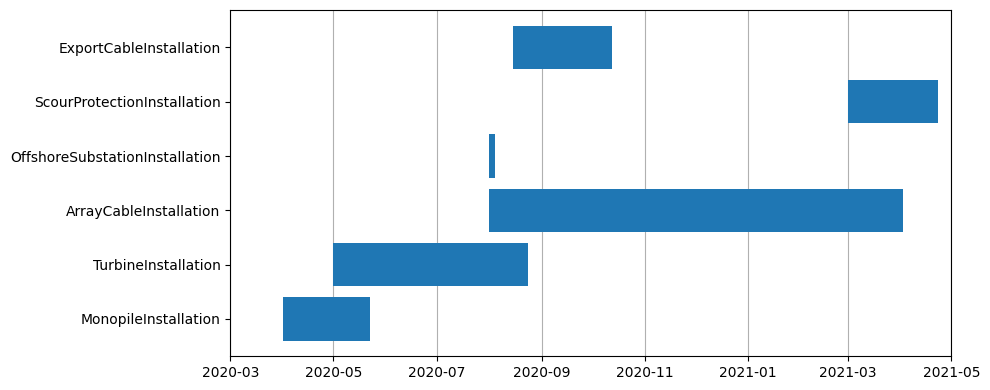

In [7]:
df = pd.DataFrame.from_dict(project.phase_dates).T
df.start = pd.to_datetime(df.start)
df.end = pd.to_datetime(df.end)
df.sort_values("start")

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.barh(y=df.index, width=df.end - df.start, left=df.start);

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(pd.to_datetime("2020-03"), pd.to_datetime("2021-05"))
fig.tight_layout()

(phase-dependent-timing)=
### Phase Dependent Timing

The other method to configure installation phase timing is to define dependent phase completion
rates. For instance, instead of providing `"TurbineInstallation": "05/01/2020"`, we could simply
wait until 30% of the monopiles are installed by providing ``"TurbineInstallation": ("MonopileInstallation", 0.3)`. Below, we rely on dependencies instead of dates for nearly all
phases and show the results. Note, that mixed date and dependency inputs are allowed.

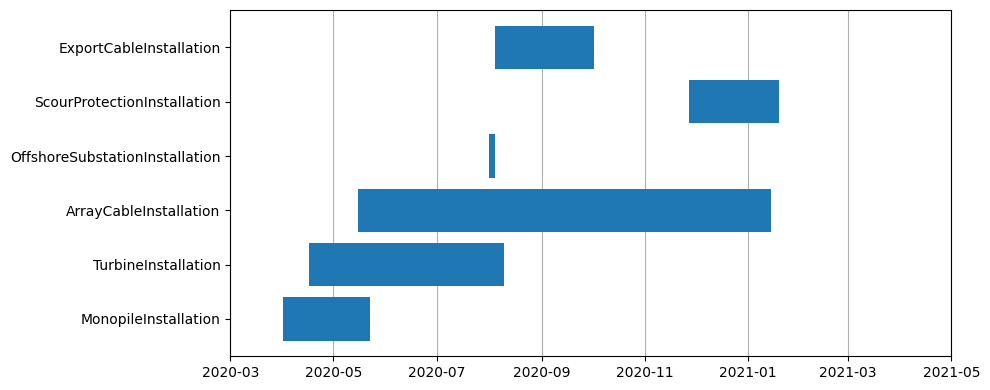

In [8]:
dependent_starts = {
    "MonopileInstallation": "04/01/2020",
    "TurbineInstallation": ("MonopileInstallation", 0.3),
    "ArrayCableInstallation": ("TurbineInstallation", 0.25),
    "OffshoreSubstationInstallation": "08/01/2020",
    "ScourProtectionInstallation": ("ArrayCableInstallation", 0.8),
    "ExportCableInstallation": ("OffshoreSubstationInstallation", 1),
}
config["install_phases"] = dependent_starts
project = ProjectManager(config)
project.run()

df = pd.DataFrame.from_dict(project.phase_dates).T
df.start = pd.to_datetime(df.start)
df.end = pd.to_datetime(df.end)
df.sort_values("start")

fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.barh(y=df.index, width=df.end - df.start, left=df.start);

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(pd.to_datetime("2020-03"), pd.to_datetime("2021-05"))
fig.tight_layout()